# Introduction : Generating Biomass capacity cost curves for EU using the ENSPRESO database


Data for this study are a combination of EU biomass potentials and costs at country level from the ENSPRESO database (Ruiz et al.,2019, 10.1016/j.esr.2019.100379), completed with excel data pretreatment. GHG emission factors  of bioenergy crops at country level are derived from the underlying study from the JRC : "The JRC-EU-TIMES model: bioenergy potentials for EU and neighbouring countries."(https://data.europa.eu/doi/10.2790/39014). GHG emission factors of residues are derived from Ecoinvent 3.9 LCA values.

#### Package imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import math

#### Database loading, scenario selection, colors

In [34]:
excel_file = "ENSPRESO_supply_curves_NUTS0.xlsx"

sheet = "HIGH 2020 NUTS0" 

df = pd.read_excel(excel_file,sheet_name=sheet)

colors = {
"SOLID": "saddlebrown",
"WET": "green",
"STARCH": "purple",
"OIL": "gold",
"RESIDUE":"grey",
"ENERGY CROP": "blue"
}

### Aggregated supply-cost curve (EU 28)


Biomass categories (SOLID, WET, STARCH, OIL) are differenciated by colors and sorted by increasing production cost.

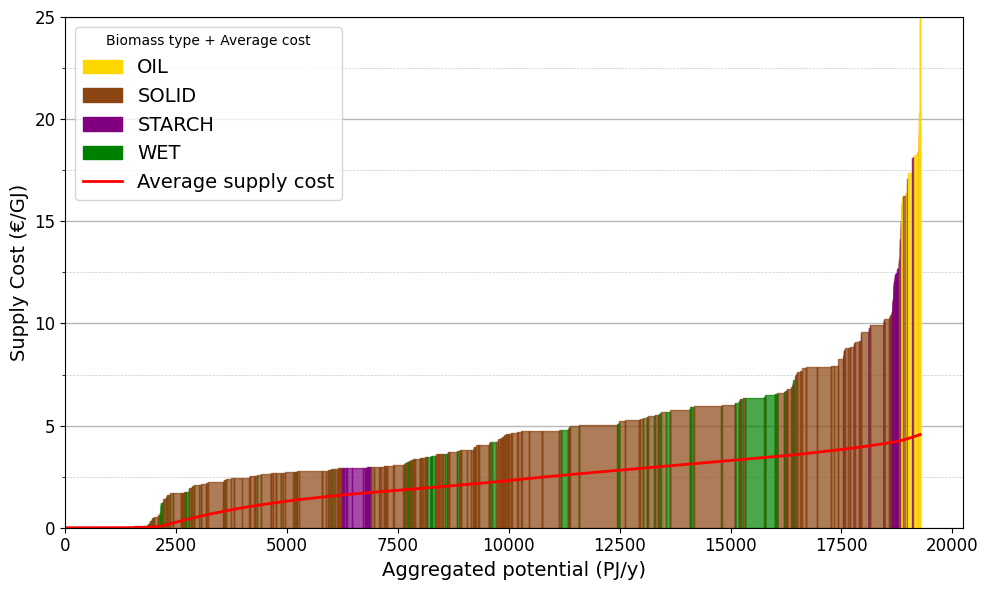

In [35]:
df = df.sort_values(by=["Cost (€/GJ)", "Category"]).reset_index(drop=True)
df["Q_start"] = df["Potential (PJ)"].cumsum().shift(fill_value=0)
df["Q_end"] = df["Potential (PJ)"].cumsum()


# --- 5) Tracer la courbe d'offre avec rectangles pleins + courbe du coût moyen ---
fig, ax = plt.subplots(figsize=(10, 6))

# Rectangles
for _, row in df.iterrows():
    ax.fill_betweenx(y=[0, row["Cost (€/GJ)"]],
                     x1=row["Q_start"], x2=row["Q_end"],
                     color=colors.get(row["Category"], "grey"), alpha=0.7, step="post")

# --- Calcul du coût moyen cumulé ---
df["cost_x_potential"] = df["Cost (€/GJ)"] * df["Potential (PJ)"]
df["cumulative_cost"] = df["cost_x_potential"].cumsum()
df["cumulative_potential"] = df["Potential (PJ)"].cumsum()
df["average_cost"] = df["cumulative_cost"] / df["cumulative_potential"]

# Tracer la courbe de coût moyen (ligne rouge épaisse)
ax.plot(df["cumulative_potential"], df["average_cost"],
        color="red", linewidth=2, label="Average supply cost")

# --- Placer la grille en arrière-plan ---
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Légende mise à jour ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
legend_handles = patches + [plt.Line2D([0], [0], color='red', lw=2, label='Average supply cost')]
ax.legend(handles=legend_handles, title='Biomass type + Average cost',fontsize=14)

# --- Limites pour partir de (0,0) ---
ax.set_xlim(0, df['Q_end'].max() * 1.05)
ax.set_ylim(0, 25)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Aggregated potential (PJ/y)", fontsize=14)
ax.set_ylabel("Supply Cost (€/GJ)", fontsize=14)
#ax.set_title("Biomass supply cost curve - EU 28 (cumulative)")
plt.tight_layout()
plt.show()

### Aggregated GHG curve (EU 28): 


Biomass categories (SOLID, WET, STARCH, OIL) are differenciated by colors

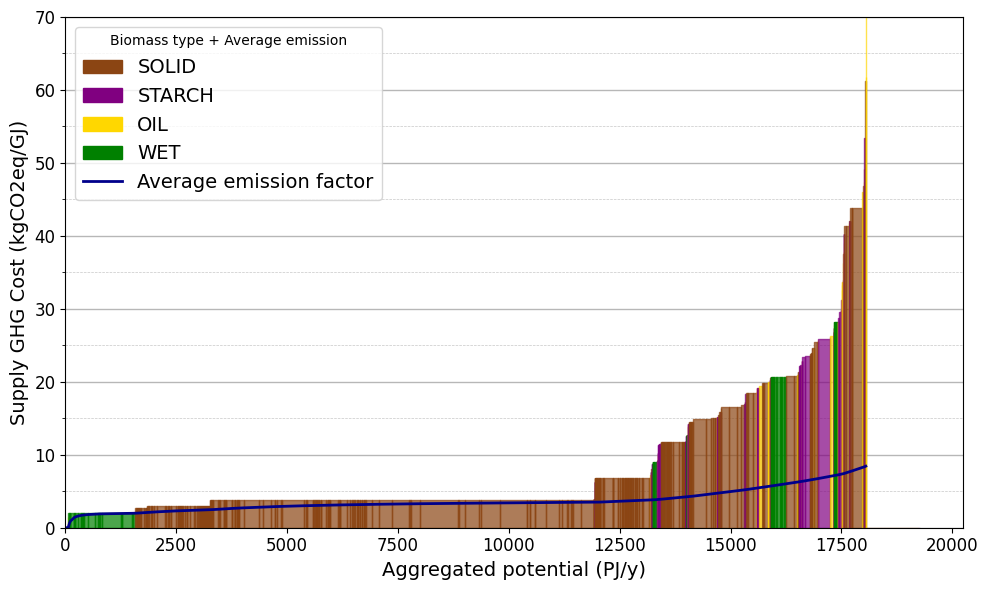

In [36]:
df = df.sort_values(by=["GHG (kgCO2eq/GJ)", "Category"]).reset_index(drop=True)
df["Q_start"] = df["Potential (PJ)"].cumsum().shift(fill_value=0)
df["Q_end"] = df["Potential (PJ)"].cumsum()

fig, ax = plt.subplots(figsize=(10, 6))

# --- Rectangles pleins ---
for _, row in df.iterrows():
    ax.fill_betweenx(y=[0, row["GHG (kgCO2eq/GJ)"]],
                     x1=row["Q_start"], x2=row["Q_end"],
                     color=colors.get(row["Category"], "grey"), alpha=0.7, step="post")

# --- Calcul du facteur d'émission moyen cumulatif ---
df["emission_x_potential"] = df["GHG (kgCO2eq/GJ)"] * df["Potential (PJ)"]
df["cumulative_emissions"] = df["emission_x_potential"].cumsum()
df["cumulative_potential"] = df["Potential (PJ)"].cumsum()
df["average_emission"] = df["cumulative_emissions"] / df["cumulative_potential"]

# Tracer la courbe de facteur d'émission moyen (ligne bleu foncé)
ax.plot(df["cumulative_potential"], df["average_emission"],
        color="darkblue", linewidth=2, label="Average emission factor")

# --- Grille et axes ---
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Légende mise à jour ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
legend_handles = patches + [plt.Line2D([0], [0], color='darkblue', lw=2, label='Average emission factor')]
ax.legend(handles=legend_handles, title='Biomass type + Average emission', fontsize=14)

# --- Limites cohérentes ---
ax.set_xlim(left=0)
ax.set_ylim(0, 70)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Aggregated potential (PJ/y)", fontsize=14)
ax.set_ylabel("Supply GHG Cost (kgCO2eq/GJ)", fontsize=14)
#ax.set_title("Biomass GHG supply cost curve - EU 28 (cumulative)")
plt.tight_layout()
plt.show()

### Supply-cost curves (EU 28) by biomass category

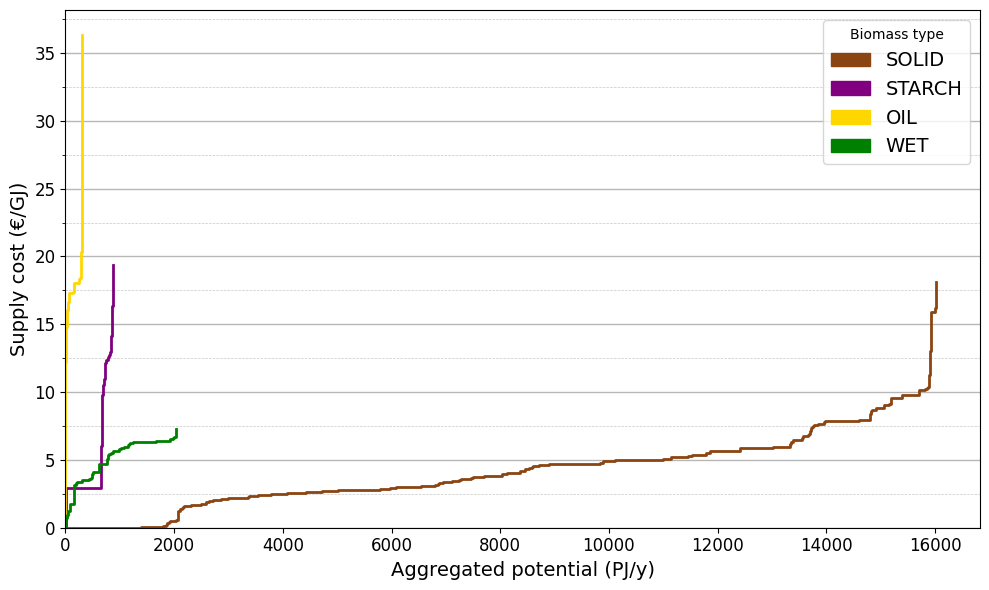

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- Placer la grille en arrière-plan ---
ax.set_axisbelow(True)

# --- Lignes secondaires sur l'axe Y ---
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))  # 2 lignes secondaires par intervalle majeur
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# --- Lignes majeures visibles plus épaisses ---
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Lignes cumulatives par type ---
for t in df['Category'].unique():
    df_t = df[df['Category'] == t].sort_values('Cost (€/GJ)')
    q_cum = df_t['Potential (PJ)'].cumsum()
    prix = df_t['Cost (€/GJ)']
    
    # Ajouter un point initial (0,0) pour chaque type
    q_points = [0] + q_cum.tolist()
    prix_points = [0] + prix.tolist()
    
    ax.step(q_points, prix_points, where='post', label=f"{t} cumulative", linewidth=2, color=colors.get(t, 'grey'))

# --- Légende ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
ax.legend(handles=patches, title='Biomass type', fontsize=14)

# --- Axes et titre ---
ax.set_xlabel('Aggregated potential (PJ/y)', fontsize=14)
ax.set_ylabel('Supply cost (€/GJ)', fontsize=14)
#ax.set_title("Biomass supply cost curves by biomass type - EU 28 (cumulative)")
ax.tick_params(axis='both', labelsize=12)
# --- Limites pour partir de (0,0) ---
ax.set_xlim(left=0)
ax.set_ylim(0, df['Cost (€/GJ)'].max() * 1.05)

plt.tight_layout()
plt.show()

GHG curves (EU 28) by biomass category

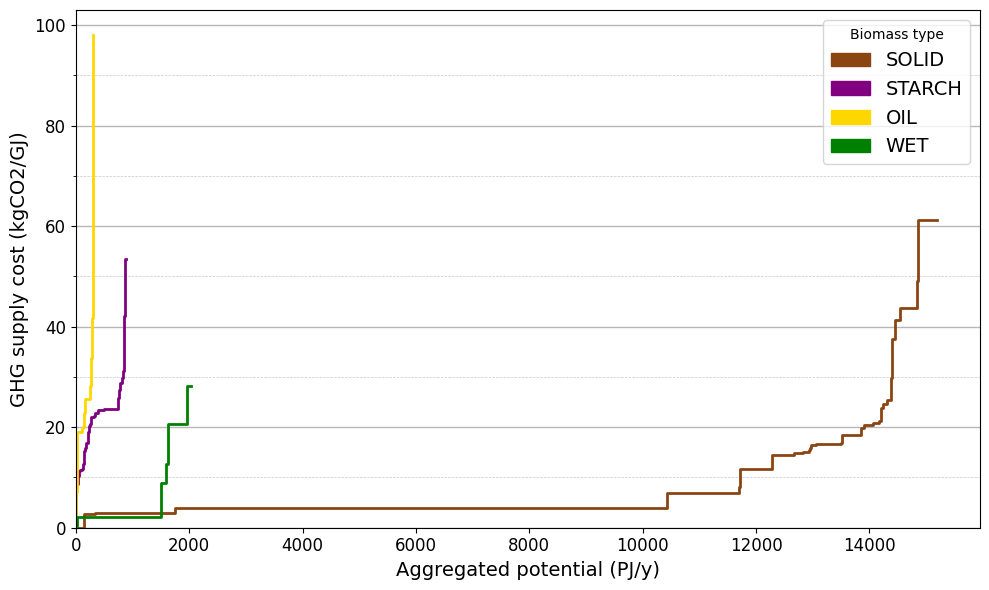

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

# --- Placer la grille en arrière-plan ---
ax.set_axisbelow(True)

# --- Lignes secondaires sur l'axe Y ---
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))  # 2 lignes secondaires par intervalle majeur
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# --- Lignes majeures visibles plus épaisses ---
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Lignes cumulatives par type ---
for t in df['Category'].unique():
    df_t = df[df['Category'] == t].sort_values('GHG (kgCO2eq/GJ)')
    q_cum = df_t['Potential (PJ)'].cumsum()
    emissions = df_t['GHG (kgCO2eq/GJ)']
    
    # Ajouter un point initial (0,0) pour chaque type
    q_points = [0] + q_cum.tolist()
    emissions_points = [0] + emissions.tolist()
    
    ax.step(q_points, emissions_points, where='post', label=f"{t} cumulative", linewidth=2, color=colors.get(t, 'grey'))

# --- Légende ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
ax.legend(handles=patches, title='Biomass type', fontsize=14)

# --- Axes et titre ---
ax.set_xlabel('Aggregated potential (PJ/y)', fontsize=14)
ax.set_ylabel('GHG supply cost (kgCO2/GJ)', fontsize=14)
#ax.set_title("Biomass GHG supply cost curves by biomass type - EU 28 (cumulative)")
ax.tick_params(axis='both', labelsize=12)
# --- Limites pour partir de (0,0) ---
ax.set_xlim(left=0)
ax.set_ylim(0, df['GHG (kgCO2eq/GJ)'].max() * 1.05)

plt.tight_layout()
plt.show()

### Supply-cost curves by biomass category and country

In [27]:
feuilles_pays = ['FR','DE','PL','ES','SE','RO','IT','FI','UK','HU','AT']

# Lecture unique (si le fichier a plusieurs feuilles, précise sheet_name)
df_all = pd.read_excel(excel_file, sheet_name=sheet, header=0)

df_all.columns = df_all.columns.str.strip()

country_col = 'NUTS0'
cost_col = 'Cost (€/GJ)'
qty_col = 'Potential (PJ)'
type_col = 'Category'



# Nettoyage
df_all[cost_col] = pd.to_numeric(df_all[cost_col], errors='coerce')
df_all[qty_col] = pd.to_numeric(df_all[qty_col], errors='coerce').fillna(0)

# Filtrer les pays voulus
df_all = df_all[df_all[country_col].isin(feuilles_pays)]

# --- Détection colonnes et calcul Prix_max & Q_max globaux ---
valid_sheets = {}
Prix_max = 0
Q_max = 0

for code, df_c in df_all.groupby(country_col):
    df_c = df_c.copy()
    total_potential = df_c[qty_col].sum()

    valid_sheets[code] = {
        'df': df_c,
        'cost_col': cost_col,
        'qty_col': qty_col,
        'type_col': type_col if type_col else None,
        'total_potential': total_potential
    }

    Prix_max = max(Prix_max, df_c[cost_col].max())
    Q_max = max(Q_max, total_potential)

# --- TRI par potentiel décroissant ---
valid_sheets = dict(sorted(valid_sheets.items(), key=lambda x: x[1]['total_potential'], reverse=True))

n_pays = len(valid_sheets)
ncols = 3
nrows = math.ceil(n_pays / ncols)


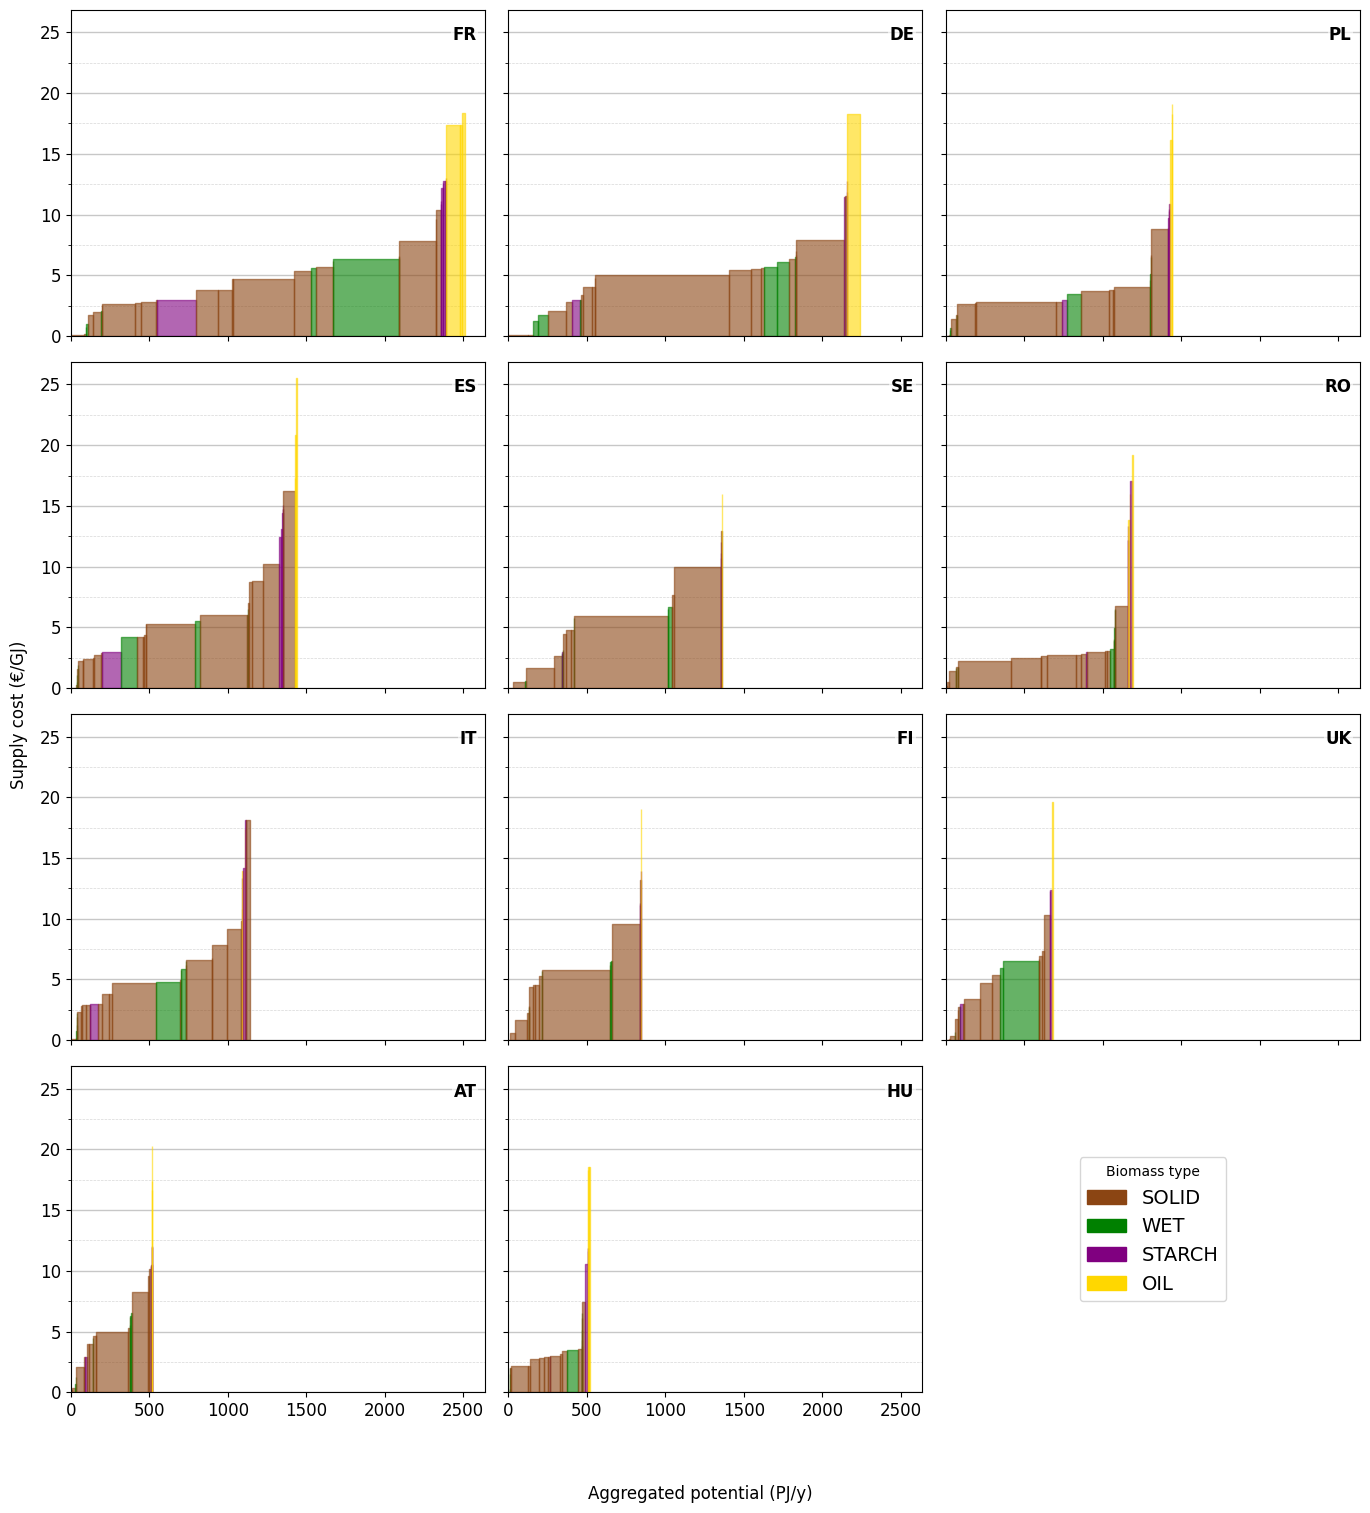

In [29]:
fig_rect, axes_rect = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))
axes_rect = axes_rect.flatten()

for i, (pays, meta) in enumerate(valid_sheets.items()):
    ax = axes_rect[i]
    df = meta['df'].copy()
    cost_col = meta['cost_col']
    qty_col = meta['qty_col']
    type_col = meta['type_col']

    df = df.sort_values(by=[cost_col] + ([type_col] if type_col else [])).reset_index(drop=True)
    df['Q_start'] = df[qty_col].cumsum().shift(fill_value=0)
    df['Q_end'] = df[qty_col].cumsum()

    ax.set_axisbelow(True)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.7)

    for _, row in df.iterrows():
        tval = row[type_col] if type_col else 'ALL'
        ax.fill_betweenx([0, row[cost_col]], x1=row['Q_start'], x2=row['Q_end'],
                         color=colors.get(tval, 'grey'), alpha=0.6, step='post')

    ax.set_xlim(0, Q_max*1.05)
    ax.set_ylim(0, Prix_max*1.05)
    ax.tick_params(axis='both', labelsize=12)
    # nom du pays dans la zone graphique (coin haut droit)
    ax.text(0.98, 0.95, pays, ha='right', va='top', transform=ax.transAxes,
            fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    if i % ncols != 0: ax.set_yticklabels([])
    if i < ncols*(nrows-1): ax.set_xticklabels([])

# garder exactement une case vide (celle juste après les pays)
empty_idx = len(valid_sheets)

for j in range(len(valid_sheets), len(axes_rect)):
    if j == empty_idx:
        axes_rect[j].axis('off')  # on garde l'axe pour y mettre la légende
    else:
        fig_rect.delaxes(axes_rect[j])

# légende centrée dans la case vide
empty_ax = axes_rect[empty_idx]
empty_ax.legend(
    handles=[mpatches.Patch(color=colors[k], label=k) for k in colors.keys()],
    title='Biomass type',
    fontsize=14,
    loc='center'
)

fig_rect.text(0.5, 0.01, 'Aggregated potential (PJ/y)', ha='center', fontsize=12)
fig_rect.text(0.04, 0.5, 'Supply cost (€/GJ)', va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()


### GHG curves by biomass category and country

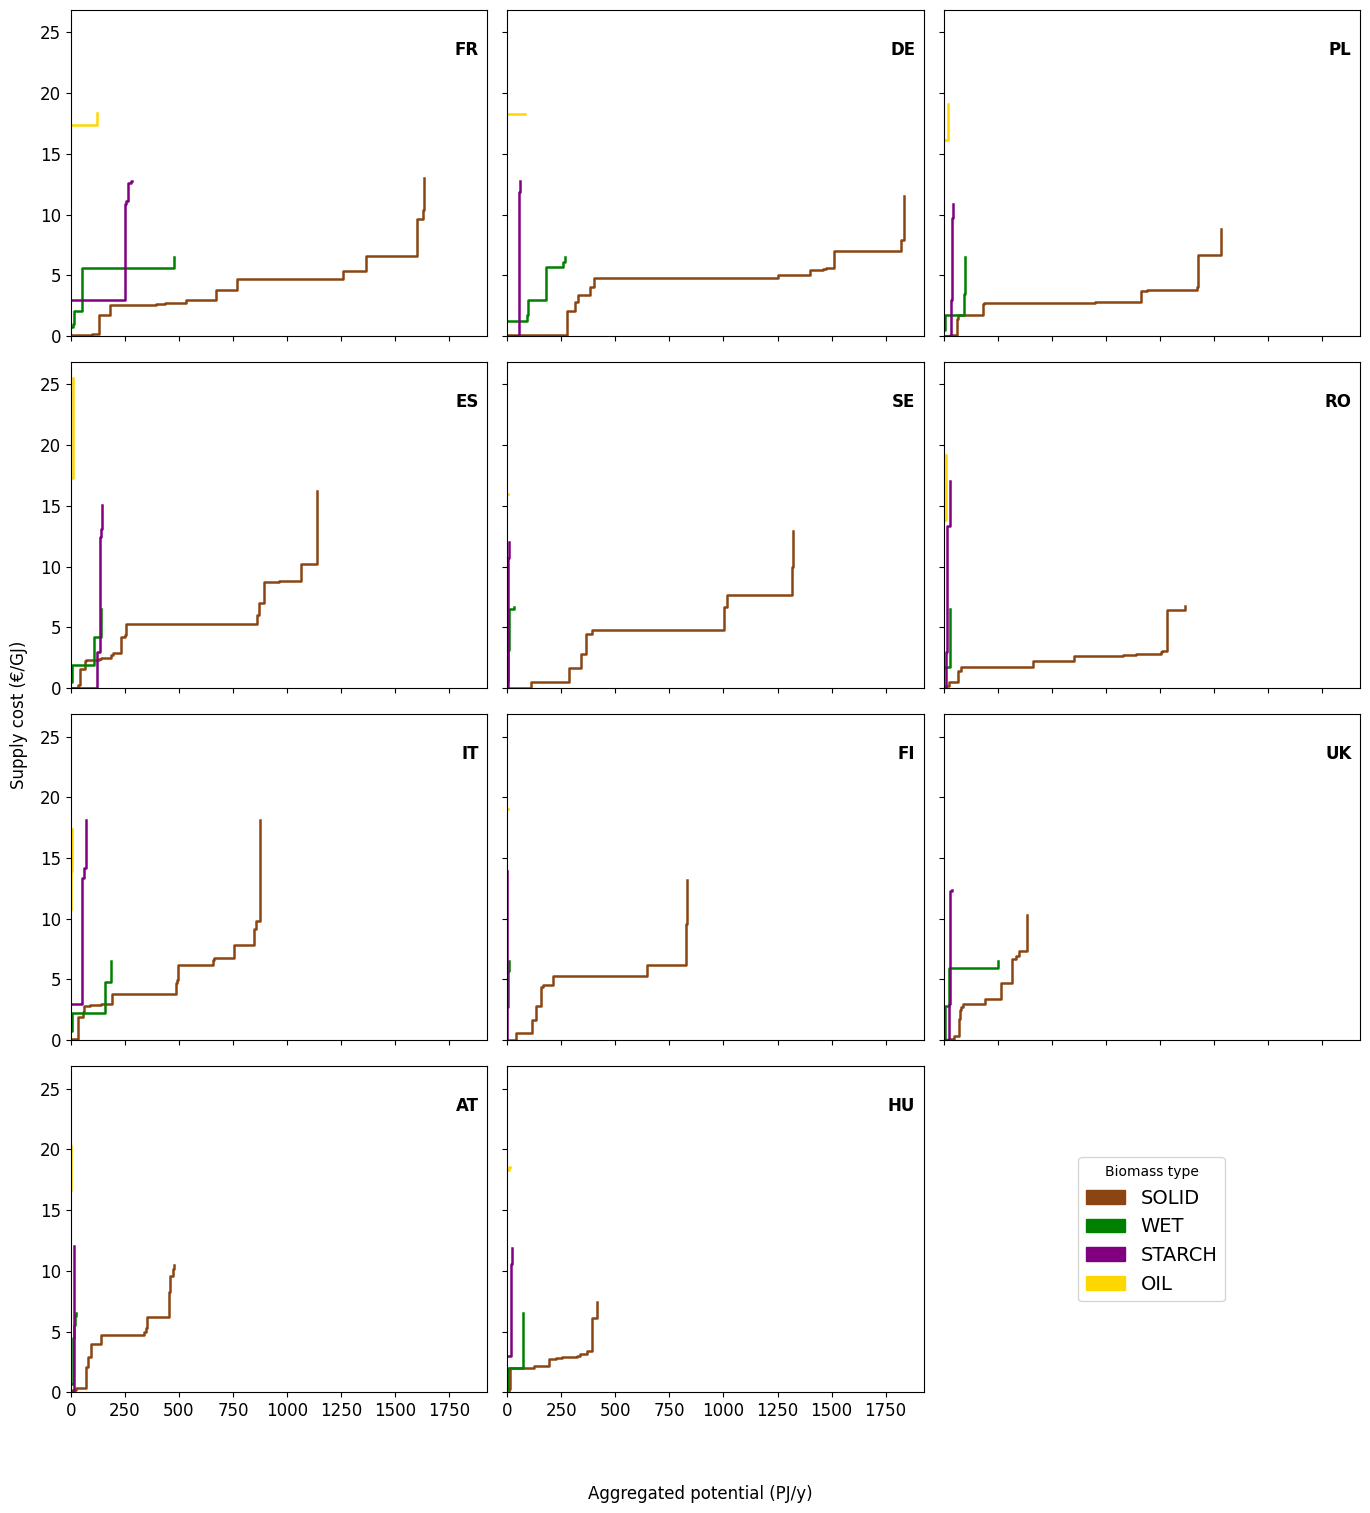

In [33]:
# --- calcul Q_max pour l'échelle X commune ---
Q_max = max(
    meta['df'].loc[meta['df'][meta['type_col']] == 'SOLID', meta['qty_col']].sum()
    for meta in valid_sheets.values()
)


fig_step, axes_step = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*5, nrows*4))
axes_step = axes_step.flatten()

for i, (pays, meta) in enumerate(valid_sheets.items()):
    ax = axes_step[i]
    df = meta['df'].copy()
    cost_col = meta['cost_col']
    qty_col = meta['qty_col']
    type_col = meta['type_col']

    types_list = df[type_col].unique() if type_col else ['ALL']
    for t in types_list:
        df_t = df[df[type_col] == t].sort_values(cost_col) if type_col else df.sort_values(cost_col)
        df_t = df_t[df_t[qty_col] > 0]
        if df_t.empty:
            continue

        q_cum = df_t[qty_col].cumsum()
        prix = df_t[cost_col]
        q_points = [0] + q_cum.tolist()
        prix_points = [prix.iloc[0]] + prix.tolist()
        ax.step(q_points, prix_points, where='post', color=colors.get(t, 'grey'), linewidth=1.8)

    ax.set_xlim(0, Q_max * 1.05)
    ax.set_ylim(0, Prix_max * 1.05)
    ax.tick_params(axis='both', labelsize=12)
    ax.text(0.98, 0.85, pays, ha='right', va='bottom', transform=ax.transAxes,
            fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    if i % ncols != 0: ax.set_yticklabels([])
    if i < ncols*(nrows-1): ax.set_xticklabels([])

# garder exactement une case vide (celle juste après les pays)
empty_idx = len(valid_sheets)

for j in range(len(valid_sheets), len(axes_step)):
    if j == empty_idx:
        axes_step[j].axis('off')  # on garde l'axe pour y mettre la légende
    else:
        fig_step.delaxes(axes_step[j])

# légende centrée dans la case vide
empty_ax = axes_step[empty_idx]
empty_ax.legend(
    handles=[mpatches.Patch(color=colors[k], label=k) for k in colors.keys()],
    title='Biomass type',
    fontsize=14,
    loc='center'
)

fig_step.text(0.5, 0.01, 'Aggregated potential (PJ/y)', ha='center', fontsize=12)
fig_step.text(0.04, 0.5, 'Supply cost (€/GJ)', va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.show()


### Supply cost curve (EU) of SOLID biomass by type (ENERGY CROP, RESIDUE)

['SOLID' 'WET' 'STARCH' 'OIL' nan]
(863, 8)
Index(['NUTS0', 'E-Comm', 'B-Com', 'Potential (PJ)', 'Cost (€/GJ)',
       'GHG (kgCO2eq/GJ)', 'Category', 'Type'],
      dtype='object')


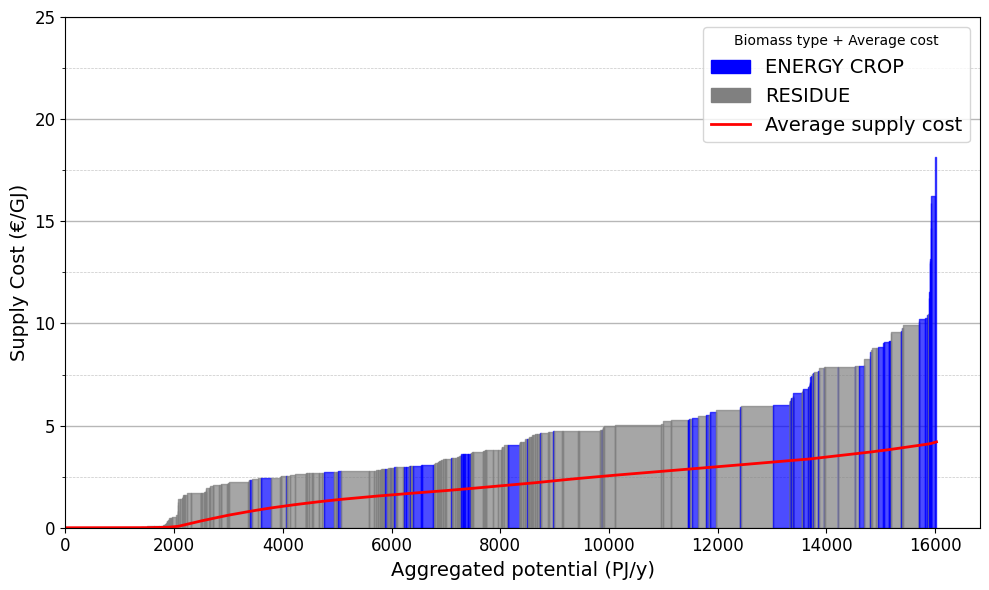

In [45]:
df = pd.read_excel(excel_file,sheet_name=sheet)

print(df["Category"].unique())

print(df.shape)
print(df.columns)

df = df[df["Category"] == "SOLID"].copy()


df = df.sort_values(by=["Cost (€/GJ)", "Type"]).reset_index(drop=True)
df["Q_start"] = df["Potential (PJ)"].cumsum().shift(fill_value=0)
df["Q_end"] = df["Potential (PJ)"].cumsum()


# --- 5) Tracer la courbe d'offre avec rectangles pleins + courbe du coût moyen ---
fig, ax = plt.subplots(figsize=(10, 6))

# Rectangles
for _, row in df.iterrows():
    ax.fill_betweenx(y=[0, row["Cost (€/GJ)"]],
                     x1=row["Q_start"], x2=row["Q_end"],
                     color=colors.get(row["Type"], "grey"), alpha=0.7, step="post")

# --- Calcul du coût moyen cumulé ---
df["cost_x_potential"] = df["Cost (€/GJ)"] * df["Potential (PJ)"]
df["cumulative_cost"] = df["cost_x_potential"].cumsum()
df["cumulative_potential"] = df["Potential (PJ)"].cumsum()
df["average_cost"] = df["cumulative_cost"] / df["cumulative_potential"]

# Tracer la courbe de coût moyen (ligne rouge épaisse)
ax.plot(df["cumulative_potential"], df["average_cost"],
        color="red", linewidth=2, label="Average supply cost")

# --- Placer la grille en arrière-plan ---
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Légende mise à jour ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Type'].dropna().astype(str).unique()]
legend_handles = patches + [plt.Line2D([0], [0], color='red', lw=2, label='Average supply cost')]
ax.legend(handles=legend_handles, title='Biomass type + Average cost',fontsize=14)

# --- Limites pour partir de (0,0) ---
ax.set_xlim(left=0)
ax.set_ylim(0, 25)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Aggregated potential (PJ/y)", fontsize=14)
ax.set_ylabel("Supply Cost (€/GJ)", fontsize=14)
#ax.set_title("SOLID biomass supply cost curve - EU 28 (cumulative)")
plt.tight_layout()
plt.show()

### GHG curve (EU) of SOLID biomass by type (ENERGY CROP, RESIDUE)

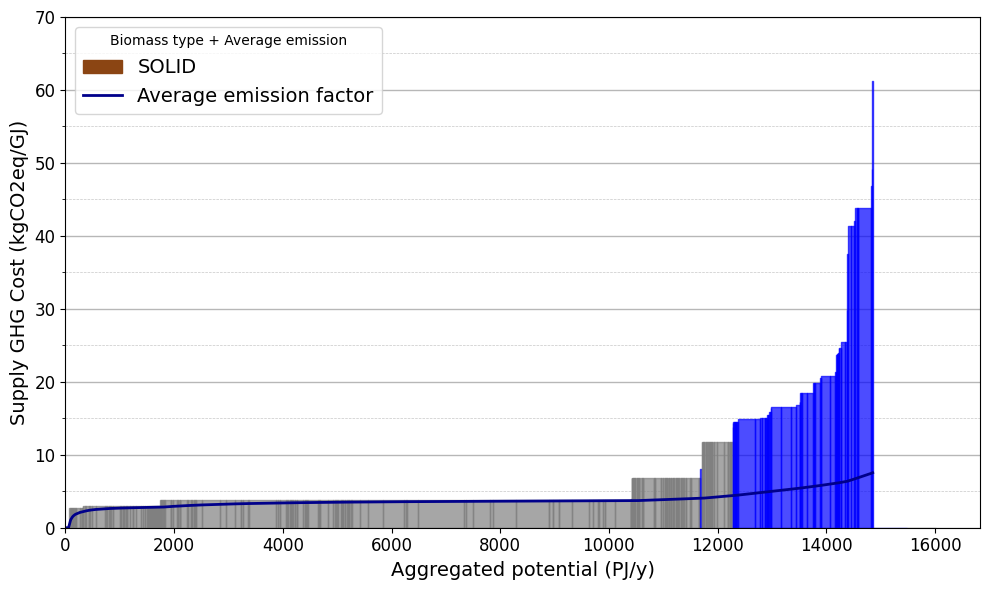

In [46]:
df = df.sort_values(by=["GHG (kgCO2eq/GJ)", "Type"]).reset_index(drop=True)
df["Q_start"] = df["Potential (PJ)"].cumsum().shift(fill_value=0)
df["Q_end"] = df["Potential (PJ)"].cumsum()

fig, ax = plt.subplots(figsize=(10, 6))

# --- Rectangles pleins ---
for _, row in df.iterrows():
    ax.fill_betweenx(y=[0, row["GHG (kgCO2eq/GJ)"]],
                     x1=row["Q_start"], x2=row["Q_end"],
                     color=colors.get(row["Type"], "grey"), alpha=0.7, step="post")

# --- Calcul du facteur d'émission moyen cumulatif ---
df["emission_x_potential"] = df["GHG (kgCO2eq/GJ)"] * df["Potential (PJ)"]
df["cumulative_emissions"] = df["emission_x_potential"].cumsum()
df["cumulative_potential"] = df["Potential (PJ)"].cumsum()
df["average_emission"] = df["cumulative_emissions"] / df["cumulative_potential"]

# Tracer la courbe de facteur d'émission moyen (ligne bleu foncé)
ax.plot(df["cumulative_potential"], df["average_emission"],
        color="darkblue", linewidth=2, label="Average emission factor")

# --- Grille et axes ---
ax.set_axisbelow(True)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(which='both', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.grid(which='major', axis='y', linestyle='-', linewidth=1, alpha=0.9)

# --- Légende mise à jour ---
patches = [mpatches.Patch(color=colors[t], label=t) for t in df['Category'].dropna().astype(str).unique()]
legend_handles = patches + [plt.Line2D([0], [0], color='darkblue', lw=2, label='Average emission factor')]
ax.legend(handles=legend_handles, title='Biomass type + Average emission', fontsize=14)

# --- Limites cohérentes ---
ax.set_xlim(left=0)
ax.set_ylim(0, 70)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("Aggregated potential (PJ/y)", fontsize=14)
ax.set_ylabel("Supply GHG Cost (kgCO2eq/GJ)", fontsize=14)
#ax.set_title("Biomass GHG supply cost curve - EU 28 (cumulative)")
plt.tight_layout()
plt.show()